In [1]:
import numpy as np 
import matplotlib.pyplot as plt 
import os 
import glob 
import psrsigsim as pss

%matplotlib inline

plt.rcParams['font.family'] = 'serif'
plt.rcParams['mathtext.fontset'] = 'dejavuserif'

2026-03-25 16:00:53.222 | DEBUG    | pint.polycos:add_polyco_file_format:629 - Registering Polyco format 'tempo' with mode='rw'


In [19]:
pss.simulate.Simulation?

Init signature:
pss.simulate.Simulation(
    fcent=None,
    bandwidth=None,
    sample_rate=None,
    dtype=<class 'numpy.float32'>,
    Npols=1,
    Nchan=512,
    sublen=None,
    fold=True,
    period=None,
    Smean=None,
    profiles=None,
    specidx=0.0,
    ref_freq=None,
    tobs=None,
    name=None,
    dm=None,
    tau_d=None,
    tau_d_ref_f=None,
    aperture=None,
    area=None,
    Tsys=None,
    tscope_name=None,
    system_name=None,
    rcvr_fcent=None,
    rcvr_bw=None,
    rcvr_name=None,
    backend_samprate=None,
    backend_name=None,
    tempfile=None,
    parfile=None,
    psrdict=None,
)
Docstring:     
convenience class for full simulations.

Necessary information includes all minimal parameters
for instances of each other class, Signal, Pulsar, ISM,
Telescope.

Input may be specified manually, from a pre-made parfile with
additional input, e.g. for the Signal, or from a premade dictionary
with appropriate keys.

Parameters
----------
fcent : float]
    Cent

In [21]:
100/0.122

819.672131147541

In [23]:
sim = pss.simulate.Simulation(
                 fcent = 150, # center frequency of observation, MHz
                 bandwidth = 100, # Bandwidth of observation, MHz
                 sample_rate = 1e-5, # 1.0*2048*10**-6, # Sampling rate of the data, MHz
                 dtype = np.float32, # data type to write out the signal in
                 Npols = 1, # number of polarizations to simulate, only one available
                 Nchan = 820, # number of subbands for the observation
                 sublen = 2.0, # length of subintegration of signal
                 fold = False, # flag to produce fold-mode, subintegrated data
                 period = 1.0, # pulsar period in seconds
                 Smean = 1.0, # mean flux of the pulsar in Jy
                 profiles = [0.5, 0.05, 1.0], # Profile - may be a data array, list of Gaussian components, or profile class object
                 tobs = 60.0, # length of observation in seconds
                 name = 'J0000+0000', # name of the simulated pulsar
                 dm = 34.0, # dispersion measure in pc cm^-3
                 tau_d = None, # scattering timescale in seconds
                 tau_d_ref_f = None, # reference frequency of scattering timescale in seconds
                 aperture = 100.0, # telescope aperture in meters
                 area = 5500.0, # telescope area in meters square
                 Tsys = 35.0, # telescope system temperature
                 tscope_name = "TestScope", # telescope name (default GBT and Arecibo available)
                 system_name = "TestSys", # observing system name
                 rcvr_fcent = 430, # center frequency of the receiver in MHz
                 rcvr_bw = 100, # receiver bandwidth in MHz
                 rcvr_name ="TestRCVR", # name of receiver
                 backend_samprate = 1.5625, # bandend maximum sampling rate in MHz
                 backend_name = "TestBack", # bandend name
                 tempfile = None, # optional name of template fits file to simulate
                 psrdict = None, # optional dictionary to give for input parameters
                 )

sim.simulate()

100% dispersed in 0.024 seconds.

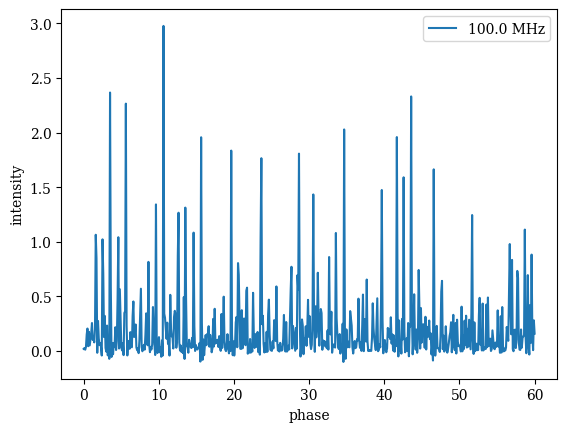

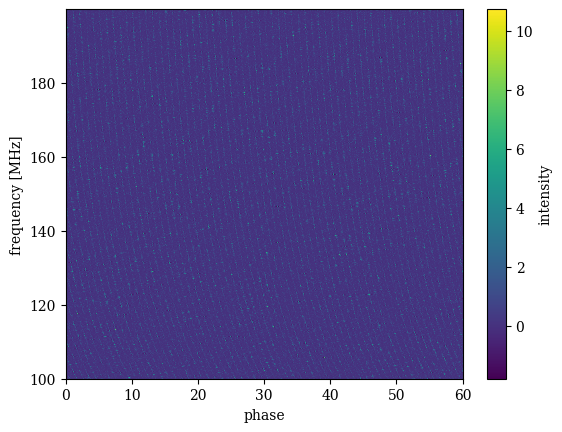

In [24]:
# Get the simulated data
sim_data = sim.signal.data

# Get the phases of the pulse
phases = np.linspace(0, sim.tobs/sim.period, len(sim_data[0,:]))
# Plot just the pulses in the first frequency channels
plt.plot(phases, sim_data[0,:], label = sim.signal.dat_freq[0])
plt.ylabel("intensity")
plt.xlabel("phase")
plt.legend(loc = 'best')
plt.show()
plt.close()

# Make the 2-D plot of intensity v. frequency and pulse phase. You can see the slight dispersive sweep here.
plt.imshow(sim_data, aspect = 'auto', interpolation='nearest', origin = 'lower', \
           extent = [min(phases), max(phases), sim.signal.dat_freq[0].value, sim.signal.dat_freq[-1].value])
plt.ylabel("frequency [MHz]")
plt.xlabel("phase")
plt.colorbar(label = "intensity")
plt.show()
plt.close()

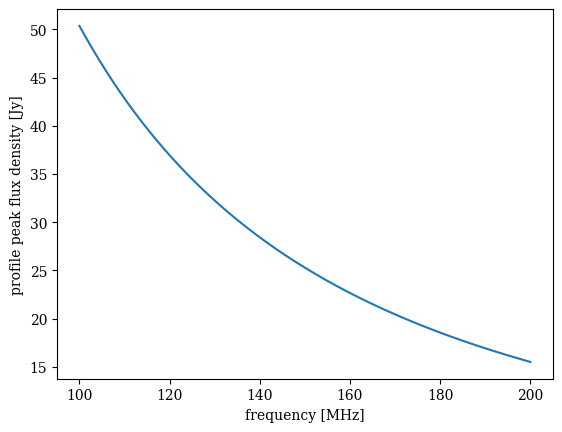

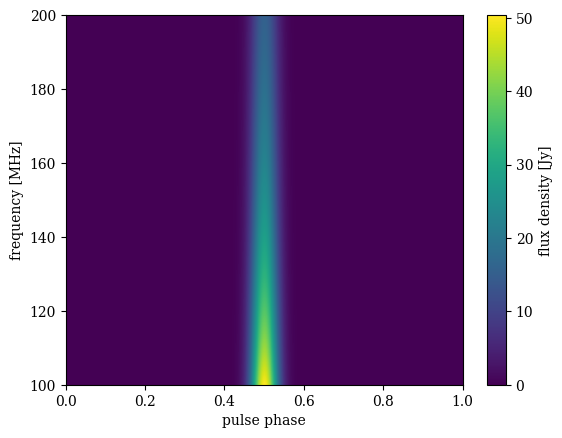

In [41]:
def gauss(x, amp, avg, sig):
    return amp * np.exp(-(x-avg)**2/(2.*sig**2))

fvec = np.linspace(100, 200, 820)
a150 = 25.3 # Jy
beta = -1.7
#avec = a150 * (fvec-150)**(beta)
avecline = beta*np.log10(fvec)
avec = 10**avecline
a150raw = avec[np.argmin(np.abs(fvec-150))]
avec *= a150/a150raw

portrait = []
for i in range(len(fvec)):
    portrait.append(gauss(np.linspace(0,1,2048), avec[i], 0.5, 0.025))
portrait = np.array(portrait)

plt.plot(fvec, avec)
plt.xlabel('frequency [MHz]')
plt.ylabel('profile peak flux density [Jy]')
plt.show()

plt.imshow(portrait, aspect='auto', interpolation='none', origin='lower', extent=(0, 1, np.min(fvec), np.max(fvec)))
plt.xlabel('pulse phase')
plt.ylabel('frequency [MHz]')
plt.colorbar(label='flux density [Jy]')
plt.show()

In [83]:
sim = pss.simulate.Simulation(
                 fcent = 150, # center frequency of observation, MHz
                 bandwidth = 100, # Bandwidth of observation, MHz
                 sample_rate = 1.0*2048*10**-6, # Sampling rate of the data, MHz
                 dtype = np.float32, # data type to write out the signal in
                 Npols = 1, # number of polarizations to simulate, only one available
                 Nchan = 820, # number of subbands for the observation
                 sublen = 2.4, # length of subintegration of signal
                 fold = False, # flag to produce fold-mode, subintegrated data
                 period = 1.2, # pulsar period in seconds
                 Smean = 25.3, # mean flux of the pulsar in Jy
                 profiles = [0.5, 0.05, 1.0], # Profile - may be a data array, list of Gaussian components, or profile class object
                 specidx=-1.7, # spectral index
                 ref_freq=150, # reference frequency for Smean if specidx is passed
                 tobs = 10.0, # length of observation in seconds
                 name = 'J0630-2834', # name of the simulated pulsar
                 dm = 34.468, # dispersion measure in pc cm^-3
                 #tau_d = None,
                 #tau_d_ref_f=None,
                 tau_d = 7.9809e-09, # scattering timescale in seconds
                 tau_d_ref_f = 1000.0, # reference frequency of scattering timescale in seconds
                 aperture = 300.0, # telescope aperture in meters
                 area = 54000.0, # telescope area in meters square
                 Tsys = 0.0, # telescope system temperature
                 tscope_name = "HERA", # telescope name (default GBT and Arecibo available)
                 system_name = "TestSys", # observing system name
                 rcvr_fcent = 430, # center frequency of the receiver in MHz
                 rcvr_bw = 100, # receiver bandwidth in MHz
                 rcvr_name ="TestRCVR", # name of receiver
                 backend_samprate = 1.5625, # bandend maximum sampling rate in MHz
                 backend_name = "TestBack", # bandend name
                 tempfile = None, # optional name of template fits file to simulate
                 psrdict = None, # optional dictionary to give for input parameters
                 )

sim.simulate()

100% dispersed in 0.267 seconds.

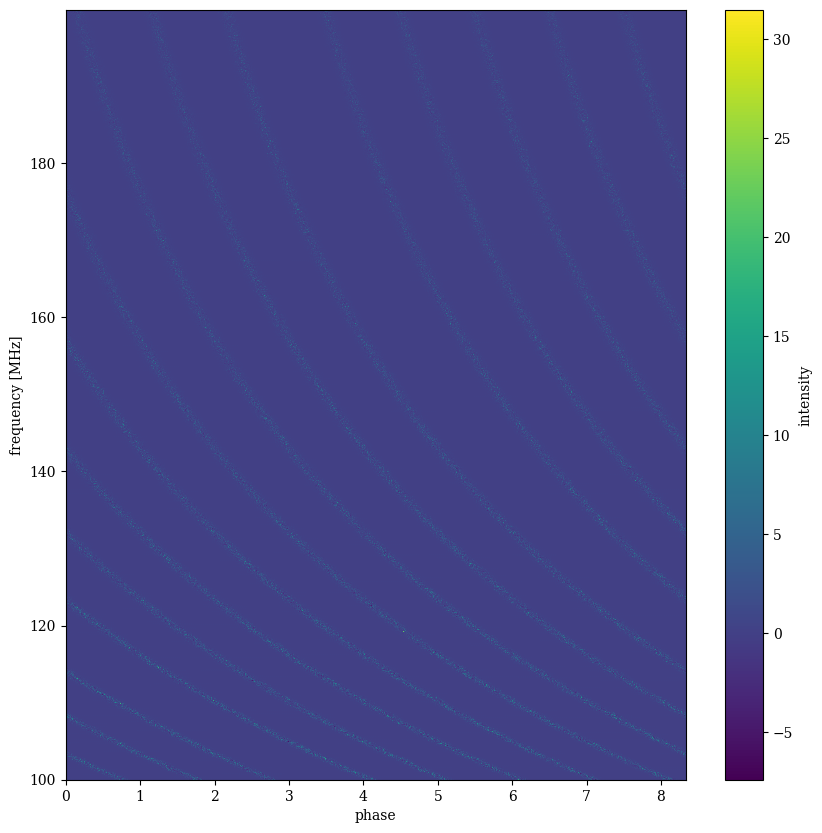

In [ ]:
sim_data = sim.signal.data

phases = np.linspace(0, sim.tobs/sim.period, len(sim_data[0,:]))

fig, ax = plt.subplots(figsize=(10,10))
plt.imshow(sim_data, aspect = 'auto', interpolation='none', origin = 'lower', \
           extent = [min(phases), max(phases), sim.signal.dat_freq[0].value, sim.signal.dat_freq[-1].value])
plt.ylabel("frequency [MHz]")
plt.xlabel("phase")
plt.colorbar(label = "intensity")
plt.show()
plt.close()

# 120 ms interleaved packet timescale for diff files
# Other estimate ~100 ms
# 9.6 s integration
# 960 subintegrations
# 480 in one stack, 480 interleaved in another stack
# difference
# then averaged down to 9.6 sec

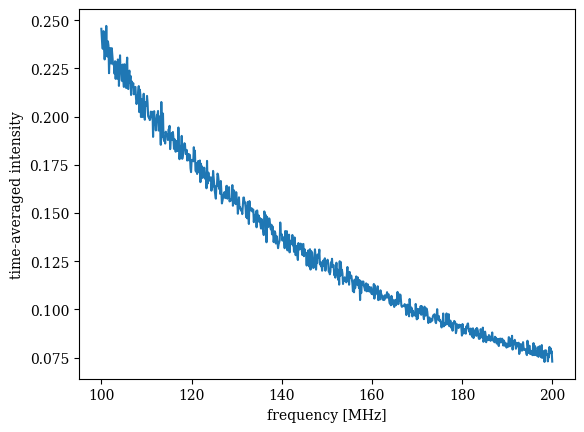

In [82]:
plt.plot(fvec, np.average(sim_data, axis=1))
plt.xlabel('frequency [MHz]')
plt.ylabel('time-averaged intensity')
plt.show()